> **Recommended: run this notebook in Google Colab, nothing to install.**
>
> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-run-a-global-case.ipynb)
>
> Just click on the "Open in Colab" button and follow along. Click the ▶ button on each cell (or press Shift+Enter) to see the results and move on to the next one.
>
> The documentation website shows pre-run results you can check if you don't want to or can't use Colab.

# Session 3: Run a global case

Navigate ships a set of **reference scenarios** under
`simulations/scenarios/` which are full decks built and maintained by the Center,
using its own assumptions (see
`simulations/scenarios/README.md`). This session works with three of them:

- `basecase_no_regulation`, `basecase_mid_regulation`, `basecase_strong_regulation`

All scenarios have the same fleet, fuel, and port assumptions, with only the regulatory
stringency varied: no `Regulation` node at all, versus the EU ETS and FuelEU plus a
moderate or an aggressive intensity-reduction scheme (a fleet-pooled,
Global-Fuel-Standard-style mechanism named `"gfs"`) phased in from 2028.


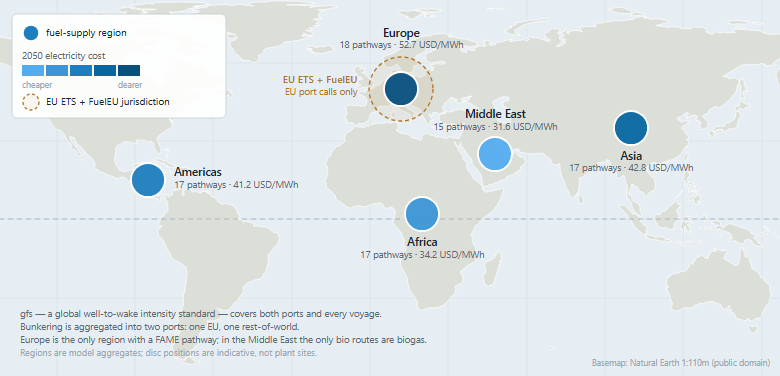

*The reference scenario's geography: five fuel-supply regions, the 2050 electricity
cost that feeds them, the production pathways each can host, and the EU jurisdiction
the ETS and FuelEU reach.*

This deck is different from the single-voyage illustrative case in [Session 1](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/01-run-a-simple-case.ipynb).
One big difference is that here, 23 fleets sail 23 routes with no endpoints, and bunkering is
aggregated into just two ports, one EU and one rest-of-world. So there is no line to
draw across the ocean. Instead, the routes in the model represent an averaged profile for the fleet.

The 84 plants in the deck are 18 production pathways replicated across five regions, less the six region-pathway combinations the deck leaves out. The difference between the copies is basically the cost of the electricity (the Middle East and Africa end up cheapest, Europe dearest, a spread of about 21 USD/MWh by 2050). Fuel logistics are not part of this simulation. The deck still loads `DefaultBunkerLogistics`, which sets no region-to-port distances, so all ten region-port pairs default to zero nautical miles at zero cost per ton-mile. Thus, for a world-level scenario, it is assumed that every region is equally close to both simulated ports.

Or in other words: geography does not really matter in this simulation.

## Setup

Running this on Colab or locally? The [workshop overview](https://github.com/zerocarbonshipping/navigate-zcs/blob/dev-workshop/docs/workshop/index.md) explains both; the cell below handles either case without changes.

In [1]:
# @title Setup
# Setup. Works both on Google Colab and in a local checkout of the repository;
# the workshop overview explains the two ways to run these notebooks.
import os
from pathlib import Path


# The branch these notebooks live on, and the one Colab clones. The "Open in
# Colab" badge at the top of the notebook, like the links between the
# notebooks, opens the copy on the workshop-colab branch instead: the same
# notebooks with their outputs cleared, rebuilt from this branch by
# .github/workflows/workshop-colab.yml. Change BRANCH, and that workflow, to
# "main" once the branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths below are relative to the repository root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# `import navigate` is not a usable test here: from the repository root it
# succeeds because the source folder is present, which leaves the `navigate`
# command itself missing.
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")

# The workshop's colours, shared with notebook 2 so the two cannot drift apart.
_STYLE_DIR = str(Path("docs/workshop").resolve())
if _STYLE_DIR not in sys.path:
    sys.path.insert(0, _STYLE_DIR)

from _style import (AXIS, GRID, INK, SUBINK, TICK, fuel_colour, fuel_label,
                    fuel_sorted, scen_colour)

Moved up to the repository root.
Navigate 1.0.0 is already installed.


## See what scenarios are available

Run this cell to check which of the Center's pre-made scenarios are available in the simulation folder.

In [2]:
# @title List the available scenarios
import os

scenarios_dir = "simulations/scenarios"
scenario_names = sorted(
    d for d in os.listdir(scenarios_dir)
    # a scenario is a folder holding a deck of its own name; 0_includes is
    # shared includes, not a scenario
    if os.path.isfile(os.path.join(scenarios_dir, d, f"{d}.nav"))
)
print("Available reference scenarios:")
for s in scenario_names:
    print(" -", s)


Available reference scenarios:
 - basecase_mid_regulation
 - basecase_no_regulation
 - basecase_strong_regulation
 - business_as_usual


## A first look at the different scenarios

In these decks the regulation is the only thing that differs between scenarios. Check how the decks of each scenario are built: 

In [3]:
# @title Compare the scenario decks
from pathlib import Path

deck_names = ["basecase_no_regulation", "basecase_mid_regulation", "basecase_strong_regulation"]


def deck_body(name):
    """A scenario's .nav file, minus the licence header, comments and blank lines."""
    text = Path(f"simulations/scenarios/{name}/{name}.nav").read_text(encoding="utf-8")
    return [line.strip() for line in text.splitlines()
            if line.strip() and not line.strip().startswith("#")]


for name in deck_names:
    print(f"{name}.nav")
    for line in deck_body(name):
        print("   ", line)
    print()

base = deck_body("basecase_no_regulation")
for name in deck_names[1:]:
    print(f"{name} adds to basecase_no_regulation:")
    for line in deck_body(name):
        if line not in base:
            print("   ", line)

print("\nbasecase_mid_regulation vs basecase_strong_regulation differ only in:")
mid_body = deck_body("basecase_mid_regulation")
for line in deck_body("basecase_strong_regulation"):
    if line not in mid_body:
        print("   ", line)


basecase_no_regulation.nav
    DEFINE {
    Load DefaultModelDefinition
    Load DefaultBunkerLogistics
    Load DefaultFleet
    Load DefaultPort
    Load DefaultEmission
    Load DefaultFeedstock
    Load DefaultFuel
    Load DefaultProducer
    Load DefaultPlant
    Load DefaultRegion
    Load DefaultSource
    Load DefaultTransport
    Load DefaultCalibration
    Load DefaultReport
    Load DefaultPlot
    Load DebugPlot
    }
    EVENTS {
    Load DefaultConverterAvailable
    Load DefaultTimeStepYearly
    }

basecase_mid_regulation.nav
    DEFINE {
    Load DefaultModelDefinition
    Load DefaultBunkerLogistics
    Load DefaultFleet
    Load DefaultPort
    Load DefaultEmission
    Load DefaultFeedstock
    Load DefaultFuel
    Load DefaultProducer
    Load DefaultPlant
    Load DefaultRegion
    Load DefaultSource
    Load DefaultTransport
    Load DefaultRegulation
    Include "../0_includes/mid_regulation.inc"
    Load DefaultCalibration
    Load DefaultReport
    Load Defaul

The main difference between the scenarios is the implemented regulation, and it comes down to
the two lines the diff above picked out. `Load DefaultRegulation` pulls the EU ETS and FuelEU
Maritime regulations out of the assumptions library, and the `Include` line adds one
scenario-specific file on top. So `basecase_no_regulation` carries no regulation at all, not the
ETS, not FuelEU, not a global standard, while the other two carry all three and differ only in
what that included file asks for.

In these example decks that scenario-specific regulation is a **Global Fuel Standard** type of regulation.

A Global Fuel Standard (GFS) is a worldwide limit on the greenhouse-gas intensity of the fuel a ship burns, tightening year on year, with penalties for exceeding the limit and rewards for using cleaner fuels. It is relatively similar to the EU FuelEU Maritime regulation, but applies worldwide rather than only to EU/EEA ports. It is a modelling assumption in these decks, not an adopted rule.


`gfs_target_reduction` is the well-to-wake GHG intensity limit every vessel is measured against, and
`gfs_remedial_unit` is the penalty for missing it. Both are defined per scenario in `simulations/scenarios/0_includes/{mid,strong}_regulation.inc`, so we can parse both decks and compare their regulatory assumptions side by side.

——————————————————————————————————————————————————————————————————————————————————————————————————
            |    |    |                                  .oO
           )_)  )_)  )_)                             __/___                  _    _
          )___))___))___)\                     _____/______|              __|_|__|_|__
         )____)____)_____)\\           _______/_____\_______\_____      _|____________|__
       _____|____|____|____\\\__       \              < < <       |    |o o o o o o o o /
~~~~~~~\                   /~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ´´´´´´´´´´´´´´´´´´´              Navigate
——————————————————————————————————————————————————————————————————————————————————————————————————
        Navigate - an integrated assessment model for decarbonizing shipping
        Developed by Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
        Version 1.0.0 - for questions, contact navigate@zerocarbonshipping.com


——————————————————————————————————————————————————————————————————————————————————————————————————
            |    |    |                                  .oO
           )_)  )_)  )_)                             __/___                  _    _
          )___))___))___)\                     _____/______|              __|_|__|_|__
         )____)____)_____)\\           _______/_____\_______\_____      _|____________|__
       _____|____|____|____\\\__       \              < < <       |    |o o o o o o o o /
~~~~~~~\                   /~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ´´´´´´´´´´´´´´´´´´´              Navigate
——————————————————————————————————————————————————————————————————————————————————————————————————
        Navigate - an integrated assessment model for decarbonizing shipping
        Developed by Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
        Version 1.0.0 - for questions, contact navigate@zerocarbonshipping.com


basecase_mid_regulation resolves 447 Forecast, 137 Curve, 30 Timetable and 8 Surface nodes

  Fuel oil (USD/ton)                 485.0 (2026)  ->    485.0 (2050)
  LNG (USD/ton)                      436.0 (2026)  ->    436.0 (2050)
  European electricity (USD/MWh)      77.1 (2025)  ->     52.7 (2050)

what the two regulation scenarios ask for, by 2050:
  GHG intensity limit      mid        28.0 gCO2eq/MJ
  GHG intensity limit      strong      0.0 gCO2eq/MJ
  penalty for missing it   mid       300.0 USD/t
  penalty for missing it   strong    800.0 USD/t


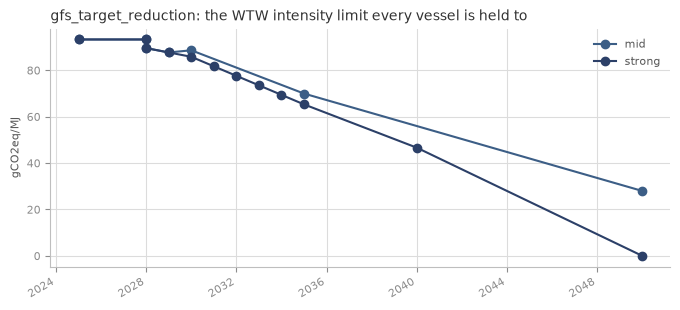

In [4]:
# @title Read the scenario assumptions
import argparse
from pathlib import Path

import pandas as pd
from navigate.manager import SimulationManager

# Same arguments the CLI would build from `-d ./assumptions`. No `-e`, because we
# are not calling manager.run() at all.
PARSE_ARGS = argparse.Namespace(data_dir=Path("./assumptions"), solver=None)


def parse_scenario(name):
    """Read a scenario deck's nodes without solving it."""
    m = SimulationManager()
    m.read_deck(Path(f"simulations/scenarios/{name}/{name}.nav"), PARSE_ARGS)
    return m


def forecast_to_frame(name, nodes):
    """A Forecast node's resolved (date, value) table, as in notebook 2."""
    node = nodes.forecasts[name]
    return pd.DataFrame({"date": pd.to_datetime(node.get_x_date()),
                         "value": [node.calculate(x) for x in node.get_x()]})


mid = parse_scenario("basecase_mid_regulation")
strong = parse_scenario("basecase_strong_regulation")

print(f"basecase_mid_regulation resolves {len(mid.nodes.forecasts)} Forecast, "
      f"{len(mid.nodes.curves)} Curve, {len(mid.nodes.timetables)} Timetable and "
      f"{len(mid.nodes.surfaces)} Surface nodes\n")

# the global prices every scenario shares
for name, label in [("fossil_fuel_oil_price_global", "Fuel oil (USD/ton)"),
                    ("liquefied_natural_gas_price_global", "LNG (USD/ton)"),
                    ("electricity_cost_europe_mid", "European electricity (USD/MWh)")]:
    df = forecast_to_frame(name, mid.nodes)
    print(f"  {label:32} {df['value'].iloc[0]:7.1f} ({df['date'].iloc[0].year})"
          f"  ->  {df['value'].iloc[-1]:7.1f} ({df['date'].iloc[-1].year})")

# and the two regulatory assumptions that separate the scenarios
print("\nwhat the two regulation scenarios ask for, by 2050:")
for name, label, unit in [("gfs_target_reduction", "GHG intensity limit", "gCO2eq/MJ"),
                          ("gfs_remedial_unit", "penalty for missing it", "USD/t")]:
    for scenario_name, nodes in (("mid", mid.nodes), ("strong", strong.nodes)):
        df = forecast_to_frame(name, nodes)
        print(f"  {label:24} {scenario_name:7} {df['value'].iloc[-1]:7.1f} {unit}")

# The .inc tables hold a fraction of the 2025 intensity, but the node also sets
# Multiplier = 93.3 and `calculate()` applies it, so everything printed and plotted
# here is already an absolute well-to-wake intensity in gCO2eq/MJ.

# the same two scenario colours the comparison figure at the end of this
# notebook uses, so "strong" is the same blue in both
ax = forecast_to_frame("gfs_target_reduction", mid.nodes).plot(
    x="date", y="value", marker="o", label="mid", figsize=(8, 3.5),
    color=scen_colour("basecase_mid_regulation"))
forecast_to_frame("gfs_target_reduction", strong.nodes).plot(
    x="date", y="value", marker="o", label="strong", ax=ax,
    color=scen_colour("basecase_strong_regulation"))
ax.set_title("gfs_target_reduction: the WTW intensity limit every vessel is held to",
             fontsize=10, color=INK, loc="left")
ax.set_xlabel("")
ax.set_ylabel("gCO2eq/MJ", fontsize=8, color=SUBINK)
ax.legend(fontsize=8, frameon=False, labelcolor=SUBINK)
ax.grid(color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TICK, labelsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)


## The sensitivity analysis

[Session 4](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-our-reference-scenarios.ipynb) runs the Center's reference scenarios exactly as they are. This one
lets you change the assumptions behind one of them and watch the answer move.

> **These numbers are for comparing, not for quoting**
>
> The scenarios here are solved on a **coarse time grid** — eight steps instead of
> twenty-five — which is what makes two solves fit inside a notebook. The next cell
> explains it. Both runs use the same grid, so the *comparison* between them is
> sound but the absolute figures are different from the Center's base simulations.

## Why this runs in a minute or two

The reference scenarios in [Session 4](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-our-reference-scenarios.ipynb) take between twelve and twenty-five minutes
each.
To have a faster solving time, we change the `EVENTS` block in this simulation to reduce the number of time steps.

```
Start
Date "01-01-2027"
Date "01-01-2030"
Date "01-01-2034"
Date "01-01-2038"
Date "01-01-2042"
Date "01-01-2046"
Date "01-01-2050"
End
```

The step is **four years** from 2030 onward (and not five), to make sure that the retrofitting mechanism (set by default to every 5 years) actually gets considered in the model.

This table shows some of the differences between a 25-step (yearly) and an 8-step run of the same scenario:

| | yearly, 25 steps | coarse, 8 steps |
|---|---|---|
| well-to-wake emissions in 2050 | 676 Mt/yr | 711 Mt/yr |
| alternative fuels in 2050 | 55.0 % | 51.8 % |
| fossil fuel oil, share of energy | 69.0 % | 72.8 % |
| hulls converted over the horizon | 1,140 | 112 |

## Setup

Run the cell below to install Navigate, prepare the sensitivities and run a reference scenario (you can choose yours among the ones available in the simulation folder by updating the SCENARIO variable at the top of the cell below).

In [5]:
# ===========================================================================
#  WHICH SCENARIO TO START FROM.  Run this cell, then the Setup cell below it.
#
#  Four reference scenarios are available in the default simulation folder.
#  The main differences between scenarios are the assumptions taken for regulation.
#  Each is a Center reference scenario under its own name, put on the workshop's eight-step grid so that
#  it solves in a minute or two instead of about twenty:
#
#    workshop_basecase_no_regulation      nothing at all - fuel chosen on cost
#    workshop_basecase_mid_regulation     EU ETS + FuelEU + a moderate fuel standard
#    workshop_basecase_strong_regulation  EU ETS + FuelEU + a strict fuel standard
#    workshop_business_as_usual           EU ETS + FuelEU, domestic fleet included
#
#  "Fuel standard" is a limit on the well-to-wake carbon intensity of the
#  energy a ship uses, tightening year on year and applied worldwide: a ship
#  above the limit pays, a ship below it earns surplus units it can sell. The
#  decks call it `gfs`.
#
#  Not every lever exists in every deck - with no regulation there is no carbon
#  price to move, and only the two middle decks carry a fuel standard. The table
#  this cell prints marks what the one you picked does not have.

SCENARIO = "workshop_basecase_mid_regulation"

# ===========================================================================

In [6]:
# @title Setup
import os
from pathlib import Path


# The branch these notebooks live on, and the one Colab clones. The "Open in
# Colab" badge at the top of the notebook, like the links between the
# notebooks, opens the copy on the workshop-colab branch instead: the same
# notebooks with their outputs cleared, rebuilt from this branch by
# .github/workflows/workshop-colab.yml. Change BRANCH, and that workflow, to
# "main" once the branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths below are relative to the repository root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# `import navigate` is not a usable test here: from the repository root it
# succeeds because the source folder is present, which leaves the `navigate`
# command itself missing.
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")

# The workshop's colours, shared with notebooks 2 and 4.
_STYLE_DIR = str(Path("docs/workshop").resolve())
if _STYLE_DIR not in sys.path:
    sys.path.insert(0, _STYLE_DIR)

from _style import (AXIS, GRID, INK, SUBINK, TICK, fuel_colour, fuel_label,
                    fuel_sorted, scen_colour)


def deck_note(nav):
    """What one deck is, read out of it rather than written down here."""
    text = nav.read_text(encoding="utf-8", errors="replace")
    if "strong_regulation.inc" in text:
        rule = "EU ETS + FuelEU + a strict fuel standard"
    elif "mid_regulation.inc" in text:
        rule = "EU ETS + FuelEU + a moderate fuel standard"
    elif "DefaultRegulation" in text:
        rule = "EU ETS + FuelEU"
    else:
        rule = "no regulation at all"
    size = ("international + domestic, 2-4 min"
            if "DefaultFleetDomestic" in text
            else "international only, 1-2 min")
    return f"{rule:43} {size}"


# every deck on the workshop's coarse grid - all four live in one folder and
# share includes/time_steps_coarse.inc
DECKS = {nav.stem: nav for nav in
         sorted(Path("simulations/scenarios/workshop_whatif").glob("*.nav"))}
assert SCENARIO in DECKS, (
    f"no deck called {SCENARIO!r}. Pick one of: {', '.join(sorted(DECKS))}")

print("decks you can start from:")
for _name, _nav in DECKS.items():
    print(f"  {'>' if _name == SCENARIO else ' '} {_name:37}{deck_note(_nav)}")
print()


# --------------------------------------------------------------------------
# The machinery: parse, change, solve, and read the results back.
# --------------------------------------------------------------------------

import argparse
import contextlib
import io
import logging
import time

import matplotlib.pyplot as plt
import numpy as np
from navigate.manager import SimulationManager

NAV = DECKS[SCENARIO]
ARGS = argparse.Namespace(data_dir=Path("./assumptions"), solver=None)

# Some levers move several forecasts at once: there is one electricity cost per
# region, and one availability share per feedstock, and a reader asking "what if
# renewable power were cheaper" means all of them.
POWER = ["electricity_cost_africa_mid", "electricity_cost_americas_mid",
         "electricity_cost_asia_mid", "electricity_cost_europe_mid",
         "electricity_cost_middle_east_mid"]
BIO = ["carbon_dioxide_biogenic_share_shipping",
       "feedstock_bioethanol_fermentation_share_shipping",
       "feedstock_biogas_share_shipping",
       "feedstock_biomethanol_gasification_share_shipping",
       "used_cooking_oil_share_shipping"]
# Every fleet grows its trade along its own segment's path, so "what if trade grew
# faster" means all fourteen of them.
GROWTH = ["trade_growth_bulk_carrier", "trade_growth_container_15000_teu",
          "trade_growth_container_1500_teu", "trade_growth_container_4500_teu",
          "trade_growth_container_8000_teu", "trade_growth_cruise",
          "trade_growth_ferry", "trade_growth_gas_carrier",
          "trade_growth_general_cargo", "trade_growth_offshore", "trade_growth_other",
          "trade_growth_roro", "trade_growth_tanker", "trade_growth_tug"]


def scale(names, factor):
    """Multiply one or more forecasts by `factor`, keeping what the deck set.

    A Forecast's value is `Multiplier x (table + Addition)`, and `set_multiplier`
    REPLACES the multiplier rather than compounding with it. Several
    forecasts ship a non-unity one - the GHG intensity limit is stored as a
    fraction with `Multiplier = 93.3` - so writing a factor straight in would not
    scale that limit, it would delete it. Reading the current value first is what
    makes every lever below mean "x the deck's own number".
    """
    names = [names] if isinstance(names, str) else names

    def tweak(m):
        for name in names:
            if name not in m.nodes.forecasts:
                continue        # this deck does not carry that assumption
            f = m.nodes.forecasts[name]
            f.set_multiplier(f.get_multiplier() * float(factor))
    return tweak


def both(*tweaks):
    """Apply several levers to one freshly parsed deck."""
    def tweak(m):
        for t in tweaks:
            if t is not None:
                t(m)
    return tweak


def run_case(tweak=None):
    """Parse the deck, optionally change it, solve it. A minute or two.

    The tweak runs between parsing and solving, on the live model objects. Each
    call re-parses, so nothing a tweak does can leak into the next run.
    """
    m = SimulationManager()
    was = logging.getLogger("navigate").level
    logging.getLogger("navigate").setLevel(logging.ERROR)   # deck warnings, not ours
    started = time.time()
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            m.read_deck(NAV, ARGS)
            if tweak is not None:
                tweak(m)
            m.run()
    finally:
        logging.getLogger("navigate").setLevel(was)
    print(f"  solved in {time.time() - started:.0f} s")
    return m


FOSSIL = {"fossil_fuel_oil", "liquefied_natural_gas"}


def fleet_cargo_miles(fleet):
    """Cargo-miles the whole fleet sailed each year: per-ship cargo-miles times hulls."""
    hulls = fleet.profile.get_existing_vessels()
    return sum(np.nan_to_num(np.asarray(hulls[v.get_name()], dtype=float))
               * np.nan_to_num(np.asarray(v.profile.get_cargo_miles(), dtype=float))
               for v in fleet.get_vessels())


def summarise(m):
    """The whole world fleet, summed over every fleet in the deck."""
    years = m.get_dateline().astype("datetime64[Y]").astype(int) + 1970
    # A solved step stands for the years up to the next one - Navigate's steps
    # look forward - and the last one for its own year. On this coarse grid a
    # horizon total therefore weights each step by that gap: unweighted, 2026
    # and 2027 would count as much as each four-year stretch after them.
    span = np.diff(np.append(years, years[-1] + 1))
    wtw = np.zeros(len(years))
    rate_x_miles, miles = np.zeros(len(years)), np.zeros(len(years))
    energy, by_year_raw, last_alt, last_all = {}, {}, 0., 0.
    for fleet in m.nodes.fleets.values():
        wtw = wtw + np.nan_to_num(np.asarray(
            fleet.profile.get_total_equivalent_WTW(), dtype=float))
        cargo_miles = fleet_cargo_miles(fleet)
        rate_x_miles = rate_x_miles + cargo_miles * np.nan_to_num(np.asarray(
            fleet.profile.get_instantaneous_freight_rate(), dtype=float))
        miles = miles + cargo_miles
        for fuel, series in fleet.profile.get_consumed_energy().items():
            values = np.nan_to_num(np.asarray(series, dtype=float))
            energy[fuel] = energy.get(fuel, 0.) + float((values * span).sum())
            by_year_raw[fuel] = by_year_raw.get(fuel, np.zeros(len(years))) + values
            last_all += float(values[-1])
            if fuel not in FOSSIL:
                last_alt += float(values[-1])
    grand = sum(energy.values())

    # the mix year by year, in EJ, stacked in Navigate's own fuel order
    by_year = {f: by_year_raw[f] / 1e9 for f in fuel_sorted(by_year_raw)
               if by_year_raw[f].sum() > 0}

    # Transport cost: the model's own INSTANTANEOUS freight rate - what the
    # trade actually cost that year - averaged over the fleets weighted by the
    # cargo-miles each one moved. Weighting matters: a plain mean would let a
    # small fleet count as much as a large one. Reported in USD per thousand
    # cargo-miles, which is the unit Navigate's own fleet_investment_metric plot
    # uses, so the two can be read side by side.
    freight = 1e3 * np.divide(rate_x_miles, miles,
                              out=np.zeros_like(miles), where=miles > 0)

    return {"years": years,
            "wtw": wtw / 1e6,                                  # Mt CO2e per year
            "cum": float((wtw * span).sum()) / 1e6,          # Mt CO2e over the horizon
            "mix": {k: 100. * v / grand for k, v in energy.items() if v > 0},
            "by_year": by_year,
            "freight": freight,                        # USD per thousand cargo-miles
            "alt_last": 100. * last_alt / last_all if last_all else 0.}


# --------------------------------------------------------------------------
# The reference run. Solved once; the scenario cell below re-solves only
# your version, so changing a number costs one solve, not two.
# --------------------------------------------------------------------------

print("solving the reference scenario ...")
reference = run_case()

ref = summarise(reference)
YEARS = ref["years"]

print(f"\ntime grid: {len(YEARS)} steps, {', '.join(str(y) for y in YEARS)}")
print()
for _label, _value, _unit in (
        (f"well-to-wake in {YEARS[0]}", f"{ref['wtw'][0]:,.0f}", "Mt CO2e/yr"),
        (f"well-to-wake in {YEARS[-1]}", f"{ref['wtw'][-1]:,.0f}", "Mt CO2e/yr"),
        ("cumulative over the horizon", f"{ref['cum']:,.0f}", "Mt CO2e"),
        (f"alternative fuels in {YEARS[-1]}", f"{ref['alt_last']:.1f}", "%")):
    print(f"  {_label:30} {_value:>9}  {_unit}")
print(f"\n  {'fuel':28} {'% of energy over the horizon':>28}")
for _f, _v in sorted(ref["mix"].items(), key=lambda kv: -kv[1]):
    print(f"  {fuel_label(_f):28} {_v:28.1f}")


def run_your_scenario():
    """Solve the levers set in the YOUR SCENARIO cell and compare with the reference.

    Reads the lever names (OIL_PRICE ... TRADE_GROWTH) from the notebook when
    it is called, so the cell that sets them only has to call this.
    """
    LEVERS = [("OIL_PRICE", OIL_PRICE, "fossil_fuel_oil_price_global"),
              ("GAS_PRICE", GAS_PRICE, "liquefied_natural_gas_price_global"),
              ("CARBON_PRICE", CARBON_PRICE, "eu_ets_carbon_credit_price"),
              ("GHG_PENALTY", GHG_PENALTY, "gfs_remedial_unit"),
              ("GHG_TARGET", GHG_TARGET, "gfs_target_reduction"),
              ("GREEN_POWER", GREEN_POWER, POWER),
              ("BIO_SUPPLY", BIO_SUPPLY, BIO),
              ("PLANT_BUILD", PLANT_BUILD, "epc_global_capacity_mid"),
              ("TRADE_GROWTH", TRADE_GROWTH, GROWTH)]

    # Trade is compounded as log(1 + growth), so a year shrinking by 100 % or more has
    # no meaning - say so here rather than let the solve fail on it.
    if min(TRADE_GROWTH * reference.nodes.forecasts[n].calculate(d)
           for n in GROWTH if n in reference.nodes.forecasts for d in _days) <= -1.:
        raise ValueError(f"TRADE_GROWTH = {TRADE_GROWTH} would make some trade shrink by "
                         "100 % or more in a year. Pick a value closer to zero.")

    CHANGED = [(name, value, target) for name, value, target in LEVERS if value != 1.0]

    # a lever whose forecasts this deck does not carry cannot move anything
    _inert = [n for n, _v, t in CHANGED
              if not any(x in reference.nodes.forecasts
                         for x in ([t] if isinstance(t, str) else t))]
    if _inert:
        _verb = "is" if len(_inert) == 1 else "are"
        print(f"{', '.join(_inert)} {_verb} not in {SCENARIO} "
              f"and will have no effect.\n")

    if not CHANGED:
        print("Every lever is still 1.0, so this would just re-solve the reference.")
        print("Change one of the numbers above and run this cell again.")
    else:
        print("solving your scenario:")
        for _name, _value, _ in CHANGED:
            print(f"  {_name:13} x {_value}")
        yours = run_case(both(*[scale(t, v) for _, v, t in CHANGED]))
        you = summarise(yours)
        print(f"\n  {'':28} {'reference':>11} {'yours':>11} {'change':>13}")
        for _label, _r, _y, _fmt, _pp in (
                (f"well-to-wake in {YEARS[-1]}, Mt/yr",
                 ref["wtw"][-1], you["wtw"][-1], ",.0f", False),
                ("cumulative, Mt", ref["cum"], you["cum"], ",.0f", False),
                # a share is already a percentage, so it moves in POINTS, not per cent
                (f"alternative fuels in {YEARS[-1]}, %",
                 ref["alt_last"], you["alt_last"], ".1f", True)):
            _change = (f"{_y - _r:+.1f} pp" if _pp
                       else f"{100. * (_y / _r - 1.):+.1f} %")
            print(f"  {_label:28} {_r:11{_fmt}} {_y:11{_fmt}} {_change:>13}")


        cases = {"reference": ref, "your scenario": you}
        order = ["reference", "your scenario"]
        TITLE, LABEL, TICK_SIZE = 12.5, 10.5, 10

        # Session 1's layout, drawn at the width the page shows it so the type stays
        # readable: emissions and cost on top, one fuel-mix panel per case below, on a
        # shared scale so they read against each other.
        fig = plt.figure(figsize=(11, 8.2), constrained_layout=True)
        grid = fig.add_gridspec(2, len(order), height_ratios=[1, 1.05])
        top_grid = grid[0, :].subgridspec(1, 2, wspace=0.08)
        axE = fig.add_subplot(top_grid[0, 0])
        axC = fig.add_subplot(top_grid[0, 1])
        mix_axes = [fig.add_subplot(grid[1, 0])]
        mix_axes += [fig.add_subplot(grid[1, k], sharex=mix_axes[0], sharey=mix_axes[0])
                     for k in range(1, len(order))]

        # ticks on the steps the model actually took, not a tidy sequence that
        # implies years it never solved
        steps_shown = [YEARS[0]] + [y for i, y in enumerate(YEARS[1:], 1)
                                    if y - YEARS[i - 1] >= 3]

        # ---- well-to-wake emissions -------------------------------------------
        for s in order:
            axE.plot(cases[s]["years"], cases[s]["wtw"], lw=2.4, marker=".", ms=7,
                     label=s, color=scen_colour(s))
        axE.set_title("Well-to-wake emissions", fontsize=TITLE, color=INK, loc="left")
        axE.set_ylabel("Mt CO2e per year", fontsize=LABEL, color=SUBINK)
        axE.set_ylim(bottom=0.)
        axE.legend(fontsize=LABEL, frameon=False, labelcolor=SUBINK, loc="lower left")

        # ---- transport cost ----------------------------------------------------
        # step 0 takes no decisions, so Navigate's own freight-rate plot starts at
        # the second step and so does this one. The end labels can land close
        # together, so they are spread above and below the points.
        _ends = sorted(order, key=lambda s: -cases[s]["freight"][-1])
        for k, s in enumerate(_ends):
            axC.plot(cases[s]["years"][1:], cases[s]["freight"][1:], lw=2.4, marker=".",
                     ms=7, label=s, color=scen_colour(s))
            axC.annotate(f"{cases[s]['freight'][-1]:,.1f}",
                         (cases[s]["years"][-1], cases[s]["freight"][-1]),
                         xytext=(-4 - 30 * (k // 2), 8 if k % 2 == 0 else -16),
                         textcoords="offset points", ha="right",
                         fontsize=LABEL, color=scen_colour(s), fontweight="bold")
        axC.set_title("Freight rate: what moving the cargo cost", fontsize=TITLE,
                      color=INK, loc="left")
        axC.set_ylabel("USD per thousand cargo-miles", fontsize=LABEL, color=SUBINK)
        axC.set_ylim(bottom=0.)
        # The rate carries what the fleet pays out and almost nothing it gets back.
        # The one credit in it is the revenue an operator earns selling its OWN
        # surplus compliance units - get_regulation_expenses() is remedial +
        # flexibility - surplus_revenue - which is trade inside the scheme. Navigate
        # has no rebate, feebate or green-fuel subsidy funded from what a regulator
        # collects, so a scheme that recycled its revenue would sit lower than this.
        axC.text(.03, .04,
                 "Carbon and compliance payments are in this rate." + chr(10)
                 + "None of what regulators collect is paid back:" + chr(10)
                 + "the model has no rebate or subsidy funded from it.",
                 transform=axC.transAxes, fontsize=8.5, color=SUBINK,
                 va="bottom", ha="left", linespacing=1.5)

        # ---- the fuel mix, year by year, one panel each ------------------------
        fuels = fuel_sorted({f for c in cases.values() for f in c["by_year"]})
        for ax, s in zip(mix_axes, order):
            stack = [cases[s]["by_year"].get(f, np.zeros(len(cases[s]["years"])))
                     for f in fuels]
            ax.stackplot(cases[s]["years"], *stack, colors=[fuel_colour(f) for f in fuels],
                         labels=[fuel_label(f) for f in fuels], linewidth=0, alpha=.9)
            ax.set_title(f"Fuel consumed, {s}", fontsize=TITLE, color=INK, loc="left")
            ax.margins(x=0)
        mix_axes[0].set_ylabel("EJ per year", fontsize=LABEL, color=SUBINK)
        fig.legend(*mix_axes[0].get_legend_handles_labels(), fontsize=LABEL,
                   frameon=False, labelcolor=SUBINK, ncol=min(len(fuels), 5),
                   loc="outside lower center")

        for ax in (axE, axC, *mix_axes):
            ax.set_xticks(steps_shown)
            ax.grid(color=GRID, lw=.8)
            ax.set_axisbelow(True)
            ax.tick_params(colors=TICK, labelsize=TICK_SIZE, length=0)
            for side in ("top", "right"):
                ax.spines[side].set_visible(False)
            for side in ("left", "bottom"):
                ax.spines[side].set_color(AXIS)

        fig.suptitle("  " + ",  ".join(f"{n} x {v}" for n, v, _ in CHANGED),
                     fontsize=11, color=SUBINK, x=0.01, ha="left")
        plt.show()

        _fr = (you["freight"][-1] / ref["freight"][-1] - 1.) * 100.
        print(f"freight rate in {YEARS[-1]}: reference {ref['freight'][-1]:,.1f}, "
              f"yours {you['freight'][-1]:,.1f} USD per thousand cargo-miles "
              f"({_fr:+.1f} %)")
        print("what moved most, in percentage points of the fuel mix:")
        _delta = sorted(((you["mix"].get(f, 0.) - ref["mix"].get(f, 0.), f) for f in fuels),
                        key=lambda d: -abs(d[0]))
        for _d, _f in _delta[:5]:
            print(f"  {fuel_label(_f):28} {_d:+6.1f} pp")


# ---------------------------------------------------------------------------
# The levers, with the numbers they multiply. Read off the parsed deck rather
# than typed in here, so the table follows `assumptions/` if the Center revises
# it. Units are labels, not data, so those are stated.
# ---------------------------------------------------------------------------
LEVER_SPEC = [
    ("OIL_PRICE", "fossil bunker fuel",
     ["fossil_fuel_oil_price_global"], "USD/t", 1., "{:,.0f}"),
    ("GAS_PRICE", "fossil LNG",
     ["liquefied_natural_gas_price_global"], "USD/t", 1., "{:,.0f}"),
    ("CARBON_PRICE", "EU ETS allowance",
     ["eu_ets_carbon_credit_price"], "USD/t", 1., "{:,.0f}"),
    ("GHG_PENALTY", "a ton of excess emission",
     ["gfs_remedial_unit"], "USD/t", 1., "{:,.0f}"),
    ("GHG_TARGET", "the GHG-intensity limit",
     ["gfs_target_reduction"], "gCO2eq/MJ", 1., "{:,.1f}"),
    ("GREEN_POWER", "electricity at the e-fuel plants",
     POWER, "USD/MWh", 1., "{:,.0f}"),
    ("BIO_SUPPLY", "shipping's share of the biomass",
     BIO, "%", 100., "{:,.0f}"),
    # The capacity forecast is GLOBAL new-plant capacity; shipping's producer
    # may build epc_global_share_shipping of it, so the two multiply. Scaling
    # the capacity scales the MaximumDevelopment of epc_global with it; the
    # bio and FAME producers carry their own limits and do not move.
    ("PLANT_BUILD", "fuel plants shipping's producer may build",
     ["epc_global_capacity_mid", "epc_global_share_shipping"], "plants/yr", 1.,
     "{:,.1f}", "product"),
    ("TRADE_GROWTH", "cargo trade growth, by segment",
     GROWTH, "%/yr", 100., "{:,.1f}"),
]

_days = reference.get_timeline()          # days since the deck's start date


def _lever_span(names, when, factor, fmt, mode="range"):
    """What one lever is worth at a given moment.

    Most levers move several forecasts of the same kind, so the honest summary
    is the RANGE across them. PLANT_BUILD is different: its two forecasts are a
    capacity and the share of it shipping gets, and they MULTIPLY.
    """
    seen = [reference.nodes.forecasts[n].calculate(when)
            for n in names if n in reference.nodes.forecasts]
    if not seen:
        return "--"             # not in this deck
    if mode == "product":
        value = factor
        for v in seen:
            value *= v
        return fmt.format(value)
    seen = sorted(v * factor for v in seen)
    return (fmt.format(seen[0]) if abs(seen[-1] - seen[0]) < 1e-9
            else f"{fmt.format(seen[0])}-{fmt.format(seen[-1])}")


print(f"\n  the levers, and what 1.0 means for each in {SCENARIO}")
print(f"  {'':14}{'':42}{YEARS[0]:>12}{YEARS[-1]:>12}")
for _spec in LEVER_SPEC:
    _n, _what, _nodes, _unit, _f, _fmt = _spec[:6]
    _mode = _spec[6] if len(_spec) > 6 else "range"
    print(f"  {_n:14}{_what:42}"
          f"{_lever_span(_nodes, _days[0], _f, _fmt, _mode):>12}"
          f"{_lever_span(_nodes, _days[-1], _f, _fmt, _mode):>12}   {_unit}")

_missing = [s[0] for s in LEVER_SPEC
            if not any(n in reference.nodes.forecasts for n in s[2])]
if _missing:
    print(f"\n  {', '.join(_missing)} shown as -- : this deck does not carry that")
    print("  assumption, so setting those levers will do nothing.")

Already at the repository root.
Navigate 1.0.0 is already installed.
decks you can start from:
  > workshop_basecase_mid_regulation     EU ETS + FuelEU + a moderate fuel standard  international only, 1-2 min
    workshop_basecase_no_regulation      no regulation at all                        international only, 1-2 min
    workshop_basecase_strong_regulation  EU ETS + FuelEU + a strict fuel standard    international only, 1-2 min
    workshop_business_as_usual           EU ETS + FuelEU                             international + domestic, 2-4 min

solving the reference scenario ...


  solved in 76 s

time grid: 8 steps, 2026, 2027, 2030, 2034, 2038, 2042, 2046, 2050

  well-to-wake in 2026               1,189  Mt CO2e/yr
  well-to-wake in 2050                 711  Mt CO2e/yr
  cumulative over the horizon       25,595  Mt CO2e
  alternative fuels in 2050           51.8  %

  fuel                         % of energy over the horizon
  Fuel oil                                             72.8
  Blue ammonia                                         10.1
  Bio-methane                                           9.3
  LNG                                                   5.9
  Bio-methanol                                          1.6
  FAME                                                  0.2
  e-diesel                                              0.0
  Bio-ethanol                                           0.0

  the levers, and what 1.0 means for each in workshop_basecase_mid_regulation
                                                                  2026        2050
  O

## Some of the levers

Each suggested sensitivity can be done using a multiplier for each lever: so `1.0` means that the original assumption is used.

The spans indicated in the cell below are a sensible place to start looking, not a limit —
go outside them if you want, but check the answer still makes sense when you do.

Four of these levers are prices, two are regulation, two are limits on what can
physically be supplied, and one is how much cargo there is to carry. It is worth
noticing which group the biggest effect
comes from.

The table the cell above printed is read off the parsed deck rather than typed
in here, so if the Center revises an assumption the lever follows it. The values
repeated in the code comments are a convenience copy of the same thing.

solving your scenario:
  BIO_SUPPLY    x 2.0


  solved in 68 s

                                 reference       yours        change
  well-to-wake in 2050, Mt/yr          711         614       -13.7 %
  cumulative, Mt                    25,595      24,929        -2.6 %
  alternative fuels in 2050, %        51.8        60.8       +9.0 pp


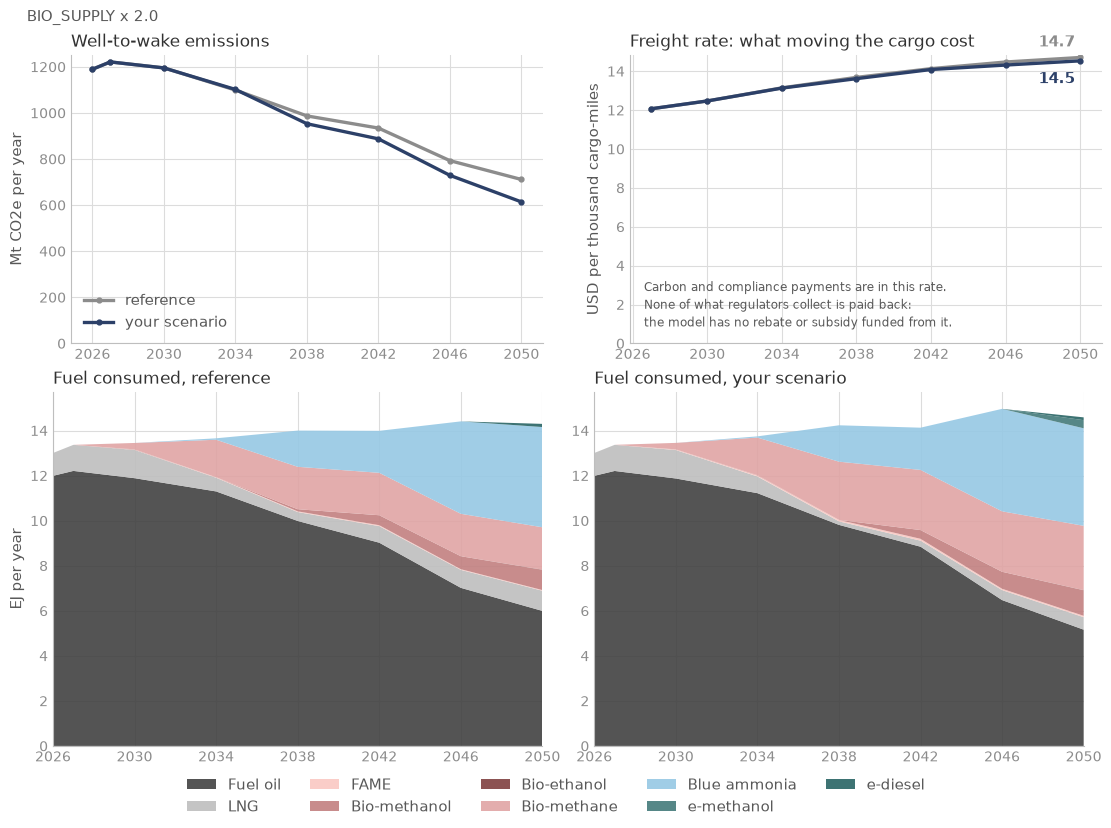

freight rate in 2050: reference 14.7, yours 14.5 USD per thousand cargo-miles (-1.2 %)
what moved most, in percentage points of the fuel mix:
  Bio-methane                    +2.8 pp
  Fuel oil                       -2.3 pp
  LNG                            -1.2 pp
  Blue ammonia                   +0.4 pp
  FAME                           +0.2 pp


In [7]:
# ===========================================================================
#  YOUR SCENARIO.  Set a lever, then run this cell: it solves your scenario
#  (a minute or two) and compares it with the reference.
#
#  Every number is a MULTIPLIER on what the deck already says, so 1.0 is the
#  reference. The right-hand column is the value being multiplied, so you can
#  judge whether a factor of two is a big change or a small one.
#
#  As an example, BIO_SUPPLY is set to 2.0: shipping gets twice the biomass.
#  Set it back to 1.0 to start from the reference.
#
#                    suggested span          what 1.0 means in the mid-regulation deck
OIL_PRICE    = 1.0   #  0.6 - 2.0     485 USD/t, flat to 2050
GAS_PRICE    = 1.0   #  0.6 - 2.0     436 USD/t, flat to 2050
CARBON_PRICE = 1.0   #  0.5 - 3.0     126 USD/t in 2026, 417 by 2050
GHG_PENALTY  = 1.0   #  0.0 - 5.0     0 until 2028, then 300 USD/t of excess
GHG_TARGET   = 1.0   #  0.5 - 1.2     93.3 gCO2eq/MJ in 2026, 28.0 by 2050
GREEN_POWER  = 1.0   #  0.6 - 1.4     58-88 USD/MWh in 2026, by region
BIO_SUPPLY   = 2.0   #  0.5 - 3.0     2-50 % of the pool, by feedstock
PLANT_BUILD  = 1.0   #  0.5 - 3.0     7.1 plants a year in 2026, rising
TRADE_GROWTH = 1.0   #  0.0 - 2.0     0.3-4.7 %/yr in 2026, by segment
#                                     1.0 = each segment's own growth; 0.0 = trade stays
#                                     at its 2026 volume; -1.0 = it shrinks as fast as it grew
#
#  GHG_TARGET below 1.0 is a STRICTER limit. The spans are a sensible place to
#  start, not a boundary - go outside them, but check the answer still makes
#  sense when you do.
# ===========================================================================

run_your_scenario()


## Do you want more?

More advanced sensitivities or personalized simulations can be done by:
- editing the deck in `simulations/scenarios/workshop_whatif/` itself,
- keeping your own variants under `simulations/user/`,
- building a case from scratch as [Session 5](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-case.ipynb) describes (needs a local checkout rather than Colab)
- you can also check out our [Horizon-zcs](https://github.com/zerocarbonshipping/horizon-zcs/tree/main) tool on GitHub for global sensitivity analysis (which is what we are using for our own analyses)

## Workshop sessions

**Next: [Session 4: Run our reference scenarios](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-our-reference-scenarios.ipynb)**

Each link opens the notebook in Google Colab, in a fresh session, so run it
from the top.

1. [Run a simple case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/01-run-a-simple-case.ipynb)
2. [Understand Navigate](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-understand-navigate.ipynb)
3. **Run a global case** (this session)
4. [Run our reference scenarios](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-our-reference-scenarios.ipynb)
5. [Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-case.ipynb)